### Dataset 1 - Urban Air Quality by City (2019-2024)

Dataset Description

This dataset provides recent air quality measurements across major global cities from 2019 to 2024.

Key Characteristics
- City-level observations
- Multi-year coverage (2019–2024)
- Pollution metrics for urban environments

Key Attributes
- Geographical attributes: City, Country

- Temporal attributes: Date, Year

- Air Pollution Indicators: Air Quality Index (AQI), PM2.5, PM10, NO₂, SO₂, CO, O

Purpose of the Dataset
- Identify pollution hotspots across cities
- Analyze seasonal pollution patterns
- Study temporal trends in urban air quality

STEP 1: Import Required Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEP 2: Load Dataset

In [18]:
df = pd.read_csv("air_quality_data.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
          city country        date        pm25        pm10        no2  \
0  Los Angeles     USA  2019-01-01   91.706116  141.153720  23.893886   
1  Los Angeles     USA  2019-02-01   83.888984  118.690653  22.607337   
2  Los Angeles     USA  2019-03-01  111.993585  136.610253  31.854044   
3  Los Angeles     USA  2019-04-01   99.237954  135.369649  29.915522   
4  Los Angeles     USA  2019-05-01   78.467567  131.962892  35.235144   

         so2        co         o3  temperature_c   humidity   wind_kph  \
0   4.664360  0.763780  32.790413      22.073607  51.286828   9.899321   
1   4.491913  0.687542  14.871689      22.199731  43.879639   7.350785   
2  18.565215  0.952052  22.561938      20.052204  46.666065  17.521810   
3  11.292842  0.688458  28.225449      16.454094  58.132954   6.161320   
4  11.542666  1.049557  11.248893      12.577195  67.275379  11.579484   

          aqi                 category  
0   93.281606                 Moderate  
1   83.207679       

STEP 3: Dataset Overview

In [7]:
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of dataset: (3600, 14)

Column Names:
Index(['city', 'country', 'date', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature_c', 'humidity', 'wind_kph', 'aqi', 'category'],
      dtype='object')

Data Types:
city              object
country           object
date              object
pm25             float64
pm10             float64
no2              float64
so2              float64
co               float64
o3               float64
temperature_c    float64
humidity         float64
wind_kph         float64
aqi              float64
category          object
dtype: object


STEP 4: Missing Values

In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
city             0
country          0
date             0
pm25             0
pm10             0
no2              0
so2              0
co               0
o3               0
temperature_c    0
humidity         0
wind_kph         0
aqi              0
category         0
dtype: int64


STEP 5: Convert Date Column

In [20]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract Year from date
df['Year'] = df['date'].dt.year

STEP 6: Remove Duplicate Rows

In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()

Duplicate rows: 0


STEP 7: Handle Missing Values

In [21]:
# Separate numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Fill numeric missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\mital\AppData\Local\Temp\ipykernel_25076\2112188043.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


STEP 8: Apply Yearly Average (Year + Country + City)

In [22]:
year_city_avg = df.groupby(['Year', 'country', 'city']).mean(numeric_only=True).reset_index()

print("\nYear + Country + City Average Data:")
print(year_city_avg.head())


Year + Country + City Average Data:
   Year    country            city        pm25        pm10        no2  \
0  2019  Argentina    Buenos Aires  112.026577  157.445324  28.906707   
1  2019  Australia       Melbourne   86.767104  119.022370  30.944158   
2  2019  Australia          Sydney  106.528892  140.271179  26.122123   
3  2019     Brazil  Rio de Janeiro   78.548156  104.638018  23.933124   
4  2019     Brazil       Sao Paulo   65.684985   91.984150  25.929709   

         so2        co         o3  temperature_c   humidity   wind_kph  \
0  10.333038  0.635967  28.801846      15.214130  57.852365  13.681974   
1   7.961766  0.626404  25.802037      16.837743  67.043594  12.828584   
2   8.778114  0.707771  36.189653      16.512315  61.349912  14.960017   
3   9.077957  0.541070  28.041755      13.301603  60.610293  11.118801   
4   6.011759  0.753022  29.794902      16.410531  55.725687  13.269271   

          aqi  
0  107.955354  
1   85.223194  
2  101.661492  
3   75.860512  

STEP 6: Export to CSV

In [23]:
year_city_avg.to_csv("air_quality_data_cleand.csv", index=False)

STEP 11: Basic Visualization

Distribution of Pollutants

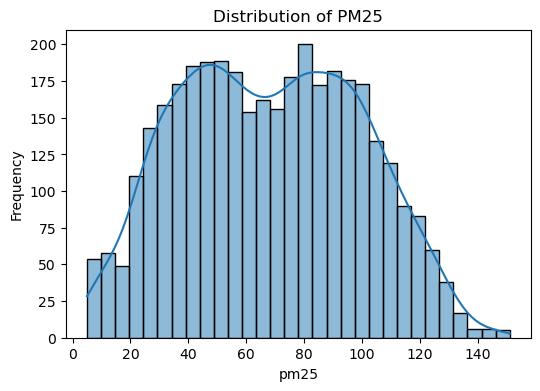

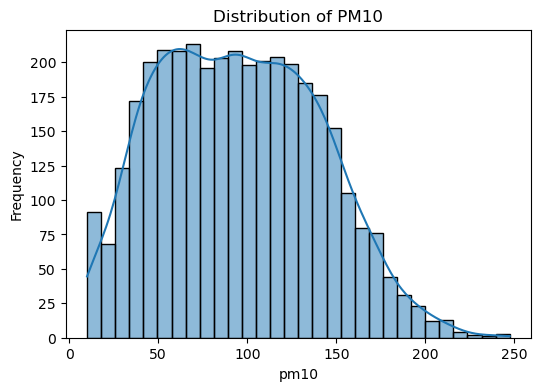

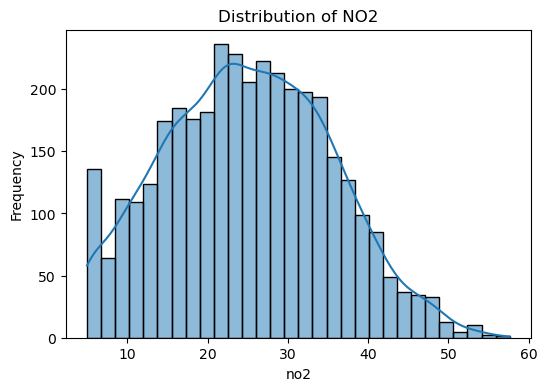

In [26]:
pollutants = ['pm25', 'pm10', 'no2']

for col in pollutants:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    
    plt.title(f"Distribution of {col.upper()}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

Pollution by Country

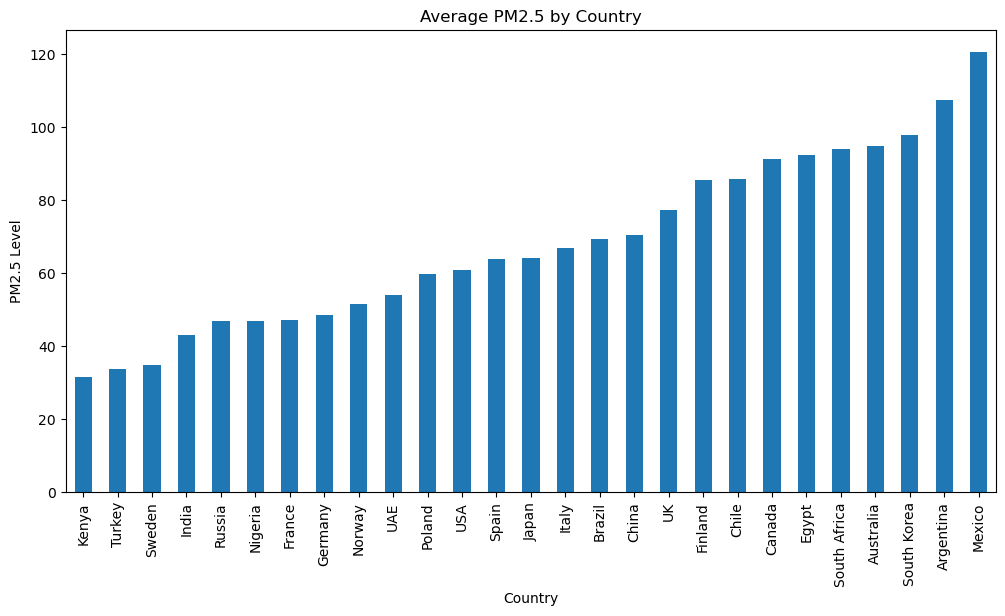

In [27]:
plt.figure(figsize=(12,6))

country_pm25 = df.groupby('country')['pm25'].mean().sort_values()

country_pm25.plot(kind='bar')

plt.title("Average PM2.5 by Country")
plt.xlabel("Country")
plt.ylabel("PM2.5 Level")

plt.show()

Top Polluted Cities

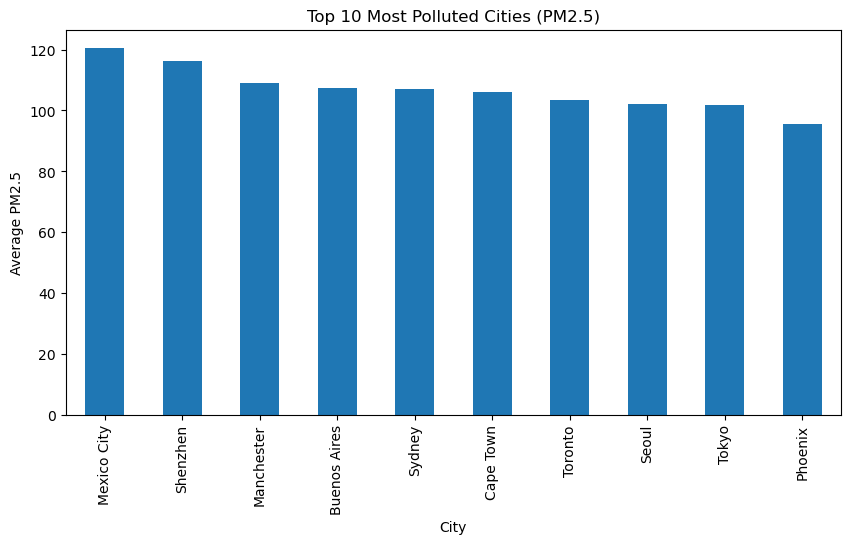

In [28]:
top_cities = df.groupby('city')['pm25'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')

plt.title("Top 10 Most Polluted Cities (PM2.5)")
plt.xlabel("City")
plt.ylabel("Average PM2.5")

plt.show()

Pollutant Correlation Matrix

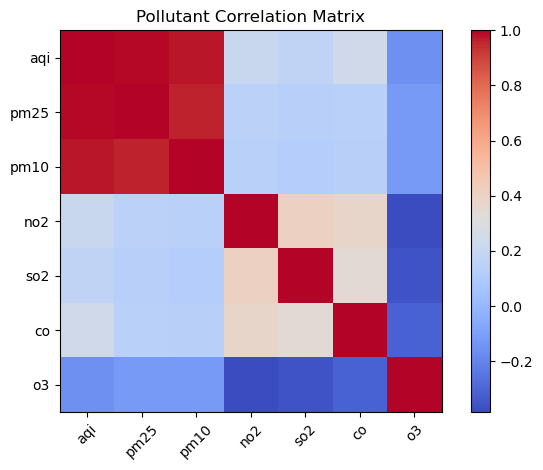

In [35]:
pollutants = ['aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
available = [col for col in pollutants if col in df.columns]

if len(available) > 1:
    corr = df[available].corr()

    plt.figure()
    plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
    plt.title("Pollutant Correlation Matrix")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


PM2.5 vs PM10

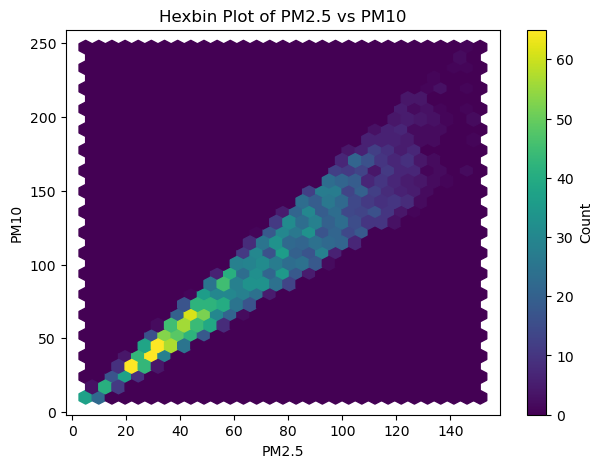

In [37]:
plt.figure(figsize=(7,5))

plt.hexbin(df['pm25'], df['pm10'], gridsize=30)

plt.colorbar(label='Count')

plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.title("Hexbin Plot of PM2.5 vs PM10")

plt.show()

### Dataset 2 - Global Climate-Health Impact Tracker (2015-2025)

This comprehensive dataset tracks the relationship between climate events and health outcomes across 25 countries from 2015 to 2025. It combines climate indicators, air quality measurements, health statistics, and socioeconomic factors to enable research on climate change impacts on public health.

Dataset Size: 14,100 records

Time Period: January 2015 - October 2025 (Weekly frequency)

Geographic Coverage: 25 countries across 8 regions

Total Features: 30 columns

Key Features:

• Climate indicators (temperature, precipitation, extreme events)

• Air quality measurements (PM2.5, AQI)

• Health outcomes (respiratory, cardiovascular, vector-borne diseases)

• Socioeconomic factors (healthcare access, GDP)

• Well being indicators (mental health, food security)

Step-1 Import libraries

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv("global_climate_health_impact_tracker_2015_2025.csv")


print("Dataset Shape:", df.shape)

Dataset Shape: (14100, 30)


In [3]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14100 entries, 0 to 14099
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     14100 non-null  int64  
 1   country_code                  14100 non-null  object 
 2   country_name                  14100 non-null  object 
 3   region                        14100 non-null  object 
 4   income_level                  14100 non-null  object 
 5   date                          14100 non-null  object 
 6   year                          14100 non-null  int64  
 7   month                         14100 non-null  int64  
 8   week                          14100 non-null  int64  
 9   latitude                      14100 non-null  float64
 10  longitude                     14100 non-null  float64
 11  population_millions           14100 non-null  int64  
 12  temperature_celsius           14100 non-null  float64
 13  t

Step-2 Clean and standardize column names

In [ ]:

df.columns = (
    df.columns
    .str.strip()              # remove leading/trailing spaces
    .str.lower()              # convert to lowercase
    .str.replace(' ', '_')    # replace spaces with underscores
    .str.replace(r'[^\w]', '', regex=True)  # remove special characters
)

print("\nCleaned Columns:")
print(df.columns)
df.dtypes


Cleaned Columns:
Index(['record_id', 'country_code', 'country_name', 'region', 'income_level',
       'date', 'year', 'month', 'week', 'latitude', 'longitude',
       'population_millions', 'temperature_celsius', 'temp_anomaly_celsius',
       'precipitation_mm', 'heat_wave_days', 'drought_indicator',
       'flood_indicator', 'extreme_weather_events', 'pm25_ugm3',
       'air_quality_index', 'respiratory_disease_rate',
       'cardio_mortality_rate', 'vector_disease_risk_score',
       'waterborne_disease_incidents', 'heat_related_admissions',
       'healthcare_access_index', 'gdp_per_capita_usd', 'mental_health_index',
       'food_security_index'],
      dtype='object')


record_id                         int64
country_code                     object
country_name                     object
region                           object
income_level                     object
date                             object
year                              int64
month                             int64
week                              int64
latitude                        float64
longitude                       float64
population_millions               int64
temperature_celsius             float64
temp_anomaly_celsius            float64
precipitation_mm                float64
heat_wave_days                    int64
drought_indicator                 int64
flood_indicator                   int64
extreme_weather_events            int64
pm25_ugm3                       float64
air_quality_index                 int64
respiratory_disease_rate        float64
cardio_mortality_rate           float64
vector_disease_risk_score       float64
waterborne_disease_incidents    float64


Step-3 Convert Data Types

In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# (Optional but recommended) Convert categorical columns
categorical_cols = [
    'country_code',
    'country_name',
    'region',
    'income_level'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Verify changes
df.dtypes

record_id                                int64
country_code                          category
country_name                          category
region                                category
income_level                          category
date                            datetime64[ns]
year                                     int64
month                                    int64
week                                     int64
latitude                               float64
longitude                              float64
population_millions                      int64
temperature_celsius                    float64
temp_anomaly_celsius                   float64
precipitation_mm                       float64
heat_wave_days                           int64
drought_indicator                        int64
flood_indicator                          int64
extreme_weather_events                   int64
pm25_ugm3                              float64
air_quality_index                        int64
respiratory_d

Step-4 Checking duplicates and missing values

In [7]:
# Check missing values per column
missing = df.isnull().sum()

# Filter only columns that actually have missing values
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print(" No missing values found in the dataset.")
else:
    print("Missing values found:")
    print(missing)

# Check if any duplicate rows exist
if df.duplicated().any():
    print(" Duplicate rows are present in the dataset.")
else:
    print(" No duplicate rows found.")

 No missing values found in the dataset.
 No duplicate rows found.


Step-5 Validate Logical Ranges

In [9]:
 # Define logical validation rules
checks = {
    'temperature_celsius': (-90, 60),
    'precipitation_mm': (0, 10000),
    'pm25_ugm3': (0, 1000),
    'air_quality_index': (0, 500),
    'population_millions': (0, 2000),
    'latitude': (-90, 90),
    'longitude': (-180, 180)
}

# Check for violations
violations = {}

for col, (low, high) in checks.items():
    if col in df.columns:
        bad = df[(df[col] < low) | (df[col] > high)]
        if not bad.empty:
            violations[col] = len(bad)

# Print results
if not violations:
    print(" No logical range violations found.")
else:
    print(" Logical range issues detected:")
    for k, v in violations.items():
        print(f"{k}: {v} rows")

 Logical range issues detected:
air_quality_index: 374 rows


In [8]:
# View offending AQI values
df.loc[(df['air_quality_index'] < 0) | (df['air_quality_index'] > 500),
       'air_quality_index'].describe()

count    374.000000
mean     -10.834225
std        8.752437
min      -52.000000
25%      -15.000000
50%       -9.000000
75%       -4.000000
max       -1.000000
Name: air_quality_index, dtype: float64

In [10]:
# See some example rows
df[(df['air_quality_index'] < 0) | (df['air_quality_index'] > 500)].head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
3,4,USA,United States,North America,High,2015-01-25,2015,1,4,37.09,...,-3,47.0,35.0,6.0,9.7,9.0,84.3,63627,68.1,96.4
10,11,USA,United States,North America,High,2015-03-15,2015,3,11,37.09,...,-23,54.1,32.0,7.3,12.3,13.6,83.2,63839,72.1,100.0
36,37,USA,United States,North America,High,2015-09-13,2015,9,37,37.09,...,-13,62.6,28.5,5.4,16.7,0.0,81.3,64474,67.7,96.6
47,48,USA,United States,North America,High,2015-11-29,2015,11,48,37.09,...,-1,47.7,33.0,10.5,24.1,0.0,82.7,64686,64.5,100.0
60,61,USA,United States,North America,High,2016-02-28,2016,2,8,37.09,...,-25,34.4,25.5,7.4,17.0,22.5,76.7,65004,64.5,94.5


Step-6 Handling negative AQI values using Median 

In [14]:
# Replace negative AQI with NaN
df.loc[df['air_quality_index'] < 0, 'air_quality_index'] = np.nan

# Check how many NaNs created
df['air_quality_index'].isna().sum()

# Fill with median AQI
df['air_quality_index'] = df['air_quality_index'].fillna(
    df['air_quality_index'].median()
)

print("AQI cleaned and imputed.")
df.sample(10, random_state=42)

AQI cleaned and imputed.


,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
811,812,IND,India,South Asia,Lower-Middle,2019-09-29,2019,9,39,20.59,...,138.0,56.5,33.7,6.0,25.7,0.0,50.7,2700,63.7,86.2
8731,8732,EGY,Egypt,Africa,Lower-Middle,2020-03-15,2020,3,11,26.82,...,175.0,83.0,29.5,4.7,23.2,20.1,41.1,4174,70.6,87.9
708,709,IND,India,South Asia,Lower-Middle,2017-10-08,2017,10,40,20.59,...,176.0,81.2,23.0,11.0,17.7,0.0,48.9,2606,67.1,88.3
1213,1214,CHN,China,East Asia,Upper-Middle,2016-08-21,2016,8,33,35.86,...,123.0,61.2,34.6,5.8,23.7,0.0,69.1,11955,69.5,100.0
1086,1087,IND,India,South Asia,Lower-Middle,2025-01-05,2025,1,1,20.59,...,159.0,87.4,25.7,4.0,26.7,0.0,46.3,2963,73.6,96.1
13744,13745,COL,Colombia,South America,Upper-Middle,2018-12-30,2018,12,52,4.57,...,134.0,88.1,23.6,17.3,26.7,0.0,73.2,9273,67.1,97.4
12527,12528,VNM,Vietnam,Southeast Asia,Lower-Middle,2017-04-16,2017,4,15,14.05,...,130.0,83.4,35.3,39.5,24.5,12.8,45.6,3519,72.2,83.5
218,219,USA,United States,North America,High,2019-03-10,2019,3,10,37.09,...,125.0,81.7,28.7,7.8,16.0,14.4,83.2,68921,65.8,90.3
5038,5039,FRA,France,Europe,High,2025-02-02,2025,2,5,46.22,...,23.0,53.7,27.6,5.9,15.1,8.7,83.4,72057,73.2,100.0
12152,12153,PHL,Philippines,Southeast Asia,Lower-Middle,2020-11-29,2020,11,48,12.87,...,221.0,96.0,28.2,3.3,21.2,0.0,40.6,3212,60.7,79.5


Step-7 Outlier Detection using IQR

In [15]:
# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    if len(outliers) > 0:
        outlier_summary[col] = len(outliers)

# Show results
if outlier_summary:
    print(" Outliers detected:")
    for k, v in sorted(outlier_summary.items(), key=lambda x: -x[1]):
        print(f"{k}: {v} rows")
else:
    print(" No significant outliers detected.")

 Outliers detected:
vector_disease_risk_score: 2345 rows
extreme_weather_events: 1829 rows
heat_wave_days: 1616 rows
population_millions: 1128 rows
heat_related_admissions: 354 rows
drought_indicator: 163 rows
waterborne_disease_incidents: 151 rows
mental_health_index: 106 rows
cardio_mortality_rate: 100 rows
flood_indicator: 83 rows
temp_anomaly_celsius: 81 rows
respiratory_disease_rate: 54 rows
food_security_index: 36 rows
air_quality_index: 25 rows
precipitation_mm: 14 rows
pm25_ugm3: 11 rows


Visualisations

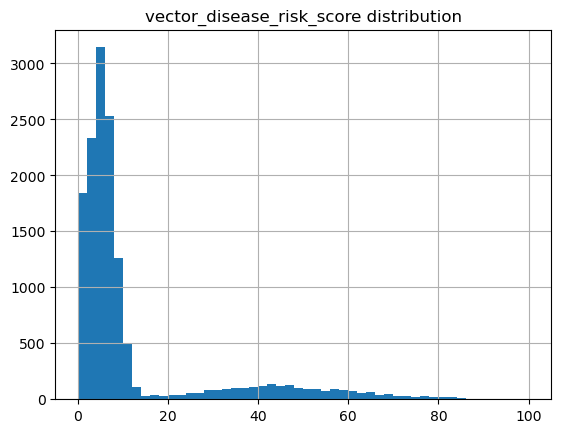

In [16]:
import matplotlib.pyplot as plt

df['vector_disease_risk_score'].hist(bins=50)
plt.title('vector_disease_risk_score distribution')
plt.show()

Applying log transform for modeling as the original data was :

heavily right-skewed

long tail of large values

many small values near zero

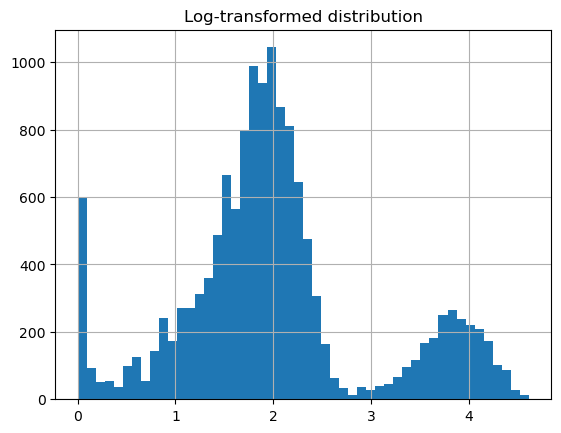

In [17]:
df['vector_disease_risk_score_log'] = np.log1p(df['vector_disease_risk_score'])
df['vector_disease_risk_score_log'].hist(bins=50)
plt.title('Log-transformed distribution')
plt.show()

Correlation Heatmap

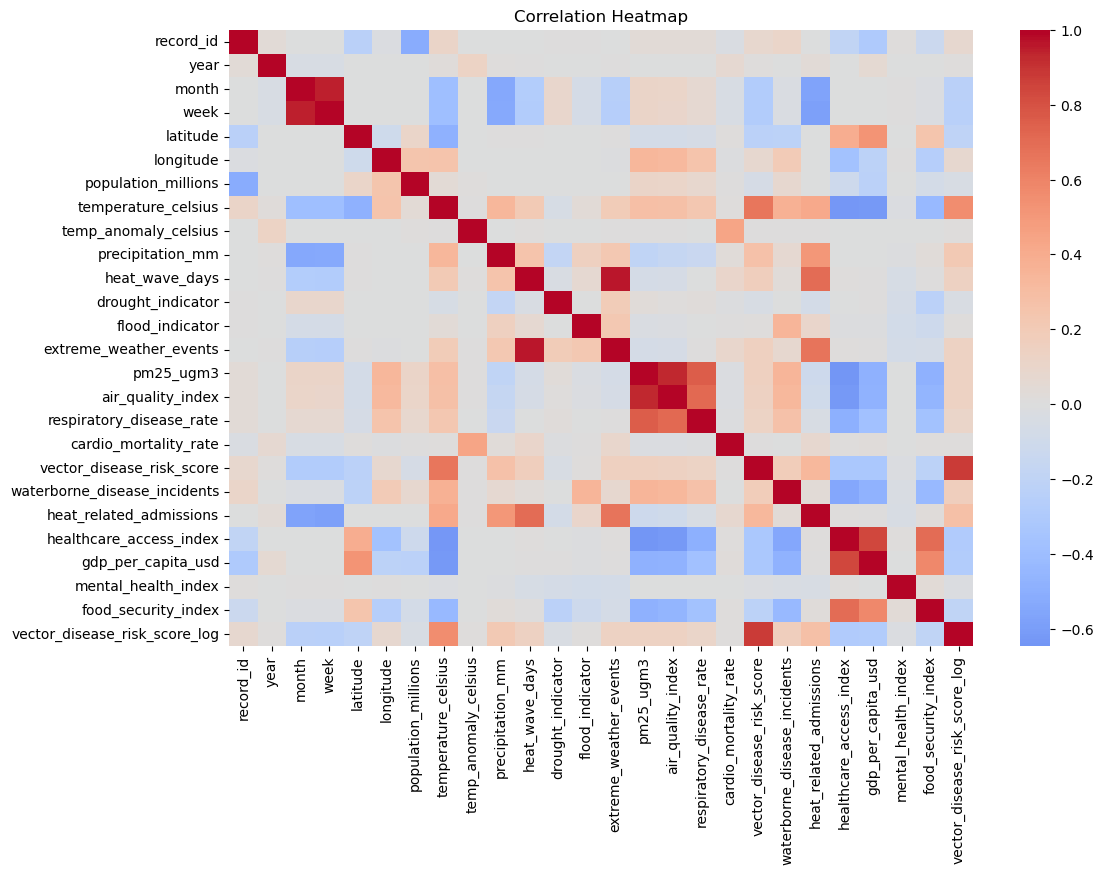

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Global temperature trend

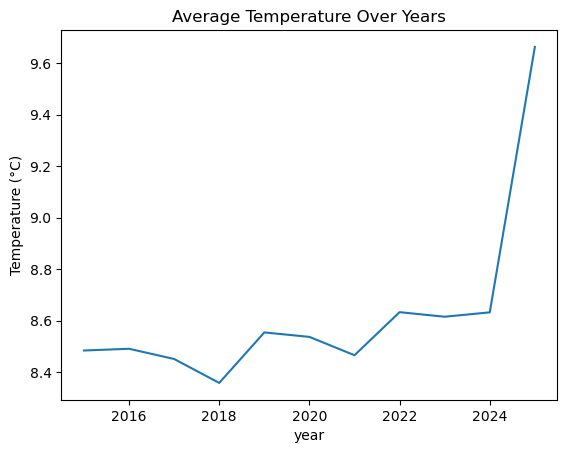

In [19]:
df.groupby('year')['temperature_celsius'].mean().plot()
plt.title('Average Temperature Over Years')
plt.ylabel('Temperature (°C)')
plt.show()

Geographic Visualisation

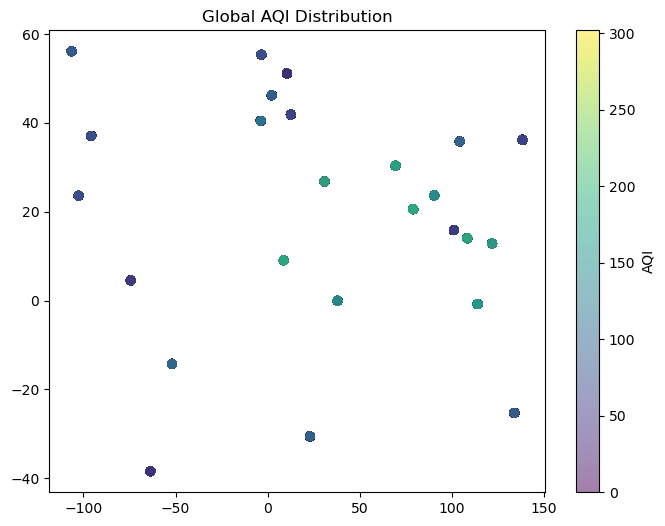

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'],
            c=df['air_quality_index'], alpha=0.5)

plt.colorbar(label='AQI')
plt.title('Global AQI Distribution')
plt.show()

Feature engineering 

We have converted the month (1–12) into circular coordinates using sine and cosine.
Even though you have year/month/week, add cyclical encoding 

Why this matters

Months are cyclical:

December (12) is close to January (1)

But raw numbers make them look far apart

The model can now detect:
* seasonal disease patterns
* winter pollution spikes
* monsoon effects
* heat seasonality

In [21]:
import numpy as np

df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

Heat stress indicator

 This is a compound climate exposure metric.

It captures:

How hot it was × how long extreme heat lasted
Very strong predictor for:

* heat-related admissions
* mortality
* vector disease spread
* mental stress

In [23]:
df['heat_stress'] = (
    df['temperature_celsius'] * df['heat_wave_days']
)


Pollution burden

This converts pollution into human exposure impact.

Because:

Pollution alone ≠ impact
Pollution × people exposed = true burden

Excellent predictor for:
* respiratory disease
* cardio mortality
* healthcare strain
* public health burden

In [25]:
df['pollution_burden'] = (
    df['pm25_ugm3'] * df['population_millions']
)

Extreme weather flag

Binary signal indicating whether any climate shock occurred.
It compresses multiple hazards into one signal.

Models often benefit from simple signals like:

"Was there a shock event or not?"

This helps capture:
* sudden system stress
* emergency conditions
* nonlinear effects



In [26]:
df['any_extreme_event'] = (
    (df['heat_wave_days'] > 0) |
    (df['flood_indicator'] == 1) |
    (df['drought_indicator'] == 1)
).astype(int)

 Health vulnerability index
 
A composite population fragility score.

It combines:
* respiratory burden
* cardiovascular risk
* mental health stress

It answers:

How medically fragile is this population overall?
This is extremely valuable because climate impacts are amplified in vulnerable populations.

Very strong for:

* mortality prediction
* climate risk modeling
* policy prioritization
* country risk ranking

In [27]:
df['health_vulnerability'] = (
    df['respiratory_disease_rate'] +
    df['cardio_mortality_rate'] +
    df['mental_health_index']
) / 3

In [28]:
# Save cleaned and engineered dataset
output_path = "global_climate_health_impact_tracker_processed.csv"

df.to_csv(output_path, index=False)

print(f" Updated dataset saved to: {output_path}")

 Updated dataset saved to: global_climate_health_impact_tracker_processed.csv


### Dataset 3 - Global Socio-Economic & Environmental Indicators

Dataset Description 

This comprehensive dataset provides a rich collection of socio-economic and environmental indicators for countries across the world. Spanning the years from 1990 to 2021, the dataset includes valuable information on Human Development Index (HDI), Life Expectancy, Gross National Income per Capita (GNI), and CO2 Production.

Dataset Size: 10,000+ records (combined across 4 CSV files)  

Time Period: 1990 to 2021  

Geographic Coverage: Global dataset covering 150+ countries  

Total Features: 20–30 variables per file (including socio-economic and environmental indicators)  

 Dataset Structure

The dataset consists of four CSV files, each representing a key global indicator:

- co2_production.csv – CO₂ emissions by country (environmental impact)  
- gross_national_income_per_capital.csv – GNI per capita (economic performance)  
- human_development_index.csv – HDI values (overall development)  
- life_expectancy_by_birth.csv – Life expectancy (population health)  

Key Features

- ISO3: Three-letter country code (ISO 3166-1 alpha-3)  
- Country: Country name  
- hdicode: Identifier related to the Human Development Index (HDI)  
- region: Geographical region or grouping  
- hdi_rank_2021: HDI rank for the year 2021  

Step 1 - Import Required Libraries 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Step 2 - Inspecting Data Structure

This step checks the structure of the datasets using functions like `.info()` and `.describe()`.  
It helps identify data types, missing values, and basic statistics.

Load all 4 dataset

In [ ]:
# Load datasets
co2 = pd.read_csv("co2_production.csv")
gni = pd.read_csv("gross_national_income_per_capital.csv")
hdi = pd.read_csv("human_development_index.csv")
life = pd.read_csv("life_expectancy_by_birth.csv")
print("Datasets loaded successfully!")


In [ ]:
# Basic information about the dataset

# Shape of each dataset
print("CO2 shape:", co2.shape)
print("GNI shape:", gni.shape)
print("HDI shape:", hdi.shape)
print("Life Expectancy shape:", life.shape)

# Duplicated rows in each dataset

print('duplicated rows in CO2:', co2.duplicated().sum())
print('duplicated rows in GNI:', gni.duplicated().sum())
print('duplicated rows in HDI:', hdi.duplicated().sum())
print('duplicated rows in Life Expectancy:', life.duplicated().sum())

# info about each dataset
print("\nCO2 Dataset Info:")
co2.info()
print("\nGNI Dataset Info:")
gni.info()  
print("\nHDI Dataset Info:")
hdi.info()
print("\nLife Expectancy Dataset Info:")
life.info()

# Describe each dataset
print("\nCO2 Dataset Description:")
print(co2.describe())
print("\nGNI Dataset Description:")
print(gni.describe())
print("\nHDI Dataset Description:")
print(hdi.describe())
print("\nLife Expectancy Dataset Description:")
print(life.describe())


Step-3 Clean and standardize column names

Column names are standardized by converting them to lowercase and replacing spaces with underscores.  
This ensures consistency and avoids errors during analysis.

In [ ]:
# Standardize column names
for df in [co2, gni, hdi, life]:
    df.columns = df.columns.str.strip().str.lower() 
    
print("Column names standardized.")

In [ ]:
# Checking column name per dataset
print("CO2 columns:", co2.columns)
print("GNI columns:", gni.columns)  
print("HDI columns:", hdi.columns)
print("Life Expectancy columns:", life.columns)

Step 4 - Data Type Conversion

Columns are converted from wide format to long format for each dataset to ensure accurate analysis and computations.

In [ ]:
# Convert wide format into long format for CO2 dataset
co2_long = co2.melt(
    id_vars=['iso3','country','hdicode','region','hdi_rank_2021'],
    var_name='year',
    value_name='co2_production'
)

co2_long['year'] = co2_long['year'].str[-4:].astype(int)

co2_long.columns
co2_long.head()

In [ ]:
# Convert wide format into long format for GNI dataset

gni.columns = gni.columns.str.strip().str.lower().str.replace(" ", "_")

gni_long = gni.melt(
    id_vars=['iso3','country','hdicode','region','hdi_rank_2021'],
    var_name='year',
    value_name='gni_per_capita'
)

gni_long['year'] = gni_long['year'].str[-4:].astype(int)

gni_long.columns    
gni_long.head()


In [ ]:
# Convert wide format into long format for HDI dataset

hdi.columns = hdi.columns.str.strip().str.lower().str.replace(" ", "_")

hdi_long = hdi.melt(
    id_vars=['iso3','country','hdicode','region','hdi_rank_2021'],
    var_name='year',
    value_name='hdi'
)

hdi_long['year'] = hdi_long['year'].str[-4:].astype(int)

hdi_long.columns
hdi_long.head()

In [ ]:
# Convert wide format into long format for Life Expectancy dataset
life.columns = life.columns.str.strip().str.lower().str.replace(" ", "_")

life_long = life.melt(
    id_vars=['iso3','country','hdicode','region','hdi_rank_2021'],
    var_name='year',
    value_name='life_expectancy'
)

life_long['year'] = life_long['year'].str[-4:].astype(int)

life_long.columns   
life_long.head()

Step 5 - Merge all 4 dataset

Multiple datasets are combined using common keys such as country name or ISO3 code and year.  
This creates a unified dataset for comprehensive analysis.

The CO₂ and GNI datasets are merged using:
- Country code (ISO3)
- Year

In [ ]:
# Merge CO2 + GNI

merged = co2_long.merge(
    gni_long[['iso3','year','gni_per_capita']],
    on=['iso3','year'],
    how='inner'
)

print("After merging CO2 + GNI:", merged.shape)
merged.head()

Adding HDI Data

The HDI dataset is merged with the existing dataset to include human development information.

In [ ]:
# Add HDI
merged = merged.merge(
    hdi_long[['iso3','year','hdi']],
    on=['iso3','year'],
    how='inner'
)

print("After adding HDI:", merged.shape)
merged.head()

Adding Life Expectancy Data

Life expectancy data is merged to complete the dataset, resulting in a comprehensive dataset containing environmental, economic, and health indicators.

In [ ]:
# Add life expentancy

merged = merged.merge(
    life_long[['iso3','year','life_expectancy']],
    on=['iso3','year'],
    how='inner'
)

print("Final merged shape:", merged.shape)
merged.head()

Step 6- Save Merged Dataset

The merged dataset is saved as a CSV file for further processing and analysis.

In [ ]:
# Save the merged dataset

merged.to_csv("merged_dataset.csv", index=False)
print("Merged dataset saved to 'merged_dataset.csv'.")

Step 7 - Dropping unnecessary columns

Aggregated regions (e.g., "World", "Europe and Central Asia") are removed to ensure analysis is performed only on individual countries.


In [ ]:
# Drop unnecessary columns
merged = merged.drop(columns=['iso3', 'hdicode', 'region', 'hdi_rank_2021'], errors='ignore')

# Check remaining columns
print(merged.columns)

# checking the length of the dataset
print("Length of merged dataset:", len(merged))

In [ ]:
# List of non-country rows to remove
remove_rows = [
    "Very high human development",
    "High human development",
    "Medium human development",
    "Low human development",
    "Arab States",
    "East Asia and the Pacific",
    "Europe and Central Asia",
    "Latin America and the Caribbean",
    "South Asia",
    "Sub-Saharan Africa",
    "World"
]

# Remove them
merged = merged[~merged['country'].isin(remove_rows)]

# Check result
print("Unique countries after cleaning:")
print(merged['country'].unique())

# checking the final length of the dataset after removing non-country rows
print("Final length of merged dataset:", len(merged))   

Step 8 - Handling Missing Values

Missing values are handled using appropriate strategies:
- GNI per capita: Filled using median (reduces impact of outliers)
- CO₂ production: Filled using mean
- HDI: Filled using country-wise averages to preserve trends

In [ ]:
# Handle missing values in the merged dataset

print("Missing values in merged dataset:")
print(merged.isnull().sum())

In [ ]:
# GNI per capita: Filled using median (reduces impact of outliers)

merged['gni_per_capita'] = merged['gni_per_capita'].fillna(
    merged['gni_per_capita'].median()
)

print(merged['gni_per_capita'].isnull().sum())


In [ ]:
# CO2 production: Filled using mean (since it's more normally distributed)
merged['co2_production'] = merged['co2_production'].fillna(
    merged['co2_production'].mean()
)

print(merged['co2_production'].isnull().sum())

In [ ]:
# HDI: Filled using mean per country (since it varies by country but is relatively stable over time)
merged['hdi'] = merged.groupby('country')['hdi'].transform(
    lambda x: x.fillna(x.mean())
)

merged['hdi'] = merged['hdi'].fillna(merged['hdi'].mean())

print(merged['hdi'].isnull().sum())

In [ ]:
# Check for missing values after filling in the merged dataset
print("Missing values in merged dataset:")
print(merged.isnull().sum())

Step 9 - Outlier Check

Descriptive statistics are used to identify potential outliers in numerical variables such as CO₂, GNI, HDI, and life expectancy.

In [ ]:
# checking outliers in the merged dataset

print(merged[['co2_production', 'gni_per_capita', 'hdi', 'life_expectancy']].describe())

Step 10 -Saving Cleaned Dataset

The final cleaned dataset is saved for analysis and visualization.

In [ ]:
# Save the merged cleaned dataset
merged.to_csv("cleaned_global_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Data Visualization

Step 1 - Import reuired libraries and load dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv('cleaned_global_dataset.csv')

# Quick check
df.head()

1. Trend of CO₂ Emissions Over Time  

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df['co2_production'], bins=30, kde=True)

plt.title("Distribution of CO₂ Production")
plt.xlabel("CO₂ Production (metric tons per capita)")
plt.ylabel("Frequency")

plt.show()


Shows global industrialization and emissions trend.

2. Trend of Life Expectancy Over Time

In [ ]:
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year].sort_values('life_expectancy', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=df_latest.head(20),  # Top 20 countries
            x='life_expectancy', 
            y='country', 
            palette='Greens_r')
plt.title(f"Top 20 Countries by Life Expectancy in {latest_year}")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Country")
plt.show()

Tracks improvement in health over time.

3. CO₂ vs HDI (Scatter Plot)

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='hdi', y='co2_production', alpha=0.6)
plt.title("CO₂ Production vs Human Development Index")
plt.xlabel("HDI")
plt.ylabel("CO₂ Production")
plt.show()

Typically, higher HDI → higher CO₂ (industrialized countries).

4. GNI vs Life Expectancy (Scatter Plot)

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gni_per_capita', y='life_expectancy', alpha=0.6)
plt.title("GNI per Capita vs Life Expectancy")
plt.xlabel("GNI per Capita (USD)")
plt.ylabel("Life Expectancy (years)")
plt.show()

Shows how income relates to longevity.

5. Correlation Heatmap

Check relationship among all numeric variables:

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['co2_production','gni_per_capita','hdi','life_expectancy']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Socioeconomic & Health Indicators")
plt.show()

Highlights strongest relationships (e.g., HDI & life expectancy, GNI & CO₂).

6. Life Expectancy Distribution

In [ ]:
selected_countries = ['India','United States','Nigeria','Germany']
plt.figure(figsize=(12,6))

for country in selected_countries:
    country_df = df[df['country'] == country]
    sns.lineplot(data=country_df, x='year', y='life_expectancy', label=country)

plt.title("Life Expectancy Over Time for Selected Countries")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.legend()
plt.show()

### Merging all 3 Dataset into one Global Dataset

Step 1 - Importing Libraries and Loading Datasets

Three datasets are loaded:
- Air Quality Dataset – contains pollution-related indicators
- Climate Health Dataset – includes climate-related health impacts
- Global Dataset – includes socioeconomic and environmental indicators



In [1]:
import pandas as pd


# Load Datasets

air_quality  = pd.read_csv("air_quality_data_cleand.csv")
climate_health = pd.read_csv("global_climate_health_impact_tracker_processed.csv")
global_dataset = pd.read_csv("cleaned_global_dataset.csv")

Step 2: Standardizing Column Names(lowercase)

In [2]:
# Standardize column names
air_quality.columns = air_quality.columns.str.lower()
climate_health.columns = climate_health.columns.str.lower()
global_dataset.columns = global_dataset.columns.str.lower()

Step 3: Rename Columns to Align Keys

The column **'country_name'** in the climate dataset is renamed to **'country'**  
to match the naming convention in other datasets.  

In [3]:
# Rename 'country_name' to 'country' in climate_health for consistency
climate_health = climate_health.rename(columns={
    'country_name': 'country'
})

Step 4: Ensure Year is integer in All Datasets

In [4]:
# Convert 'year' columns to integer type
air_quality['year'] = air_quality['year'].astype(int)
climate_health['year'] = climate_health['year'].astype(int)
global_dataset['year'] = global_dataset['year'].astype(int)

print(air_quality.dtypes)
print(climate_health.dtypes)   
print(global_dataset.dtypes)

year               int64
country           object
city              object
pm25             float64
pm10             float64
no2              float64
so2              float64
co               float64
o3               float64
temperature_c    float64
humidity         float64
wind_kph         float64
aqi              float64
dtype: object
record_id                          int64
country_code                      object
country                           object
region                            object
income_level                      object
date                              object
year                               int64
month                              int64
week                               int64
latitude                         float64
longitude                        float64
population_millions                int64
temperature_celsius              float64
temp_anomaly_celsius             float64
precipitation_mm                 float64
heat_wave_days                     int64
droug

Step 5: Fiter Each Dataset to 2019 - 2021 only

This ensures:
- Consistent time range across datasets  
- Focus on recent data for analysis  

In [5]:
# Filter datasets to include only years 2019-2021
air_quality = air_quality[(air_quality['year'] >= 2019) & (air_quality['year'] <= 2021)]
climate_health = climate_health[(climate_health['year'] >= 2019) & (climate_health['year'] <= 2021)]
global_dataset = global_dataset[(global_dataset['year'] >= 2019) & (global_dataset['year'] <= 2021)]

print(air_quality['year'].unique())
print(climate_health['year'].unique())
print(global_dataset['year'].unique())

[2019 2020 2021]
[2019 2020 2021]
[2019 2020 2021]


Step 6: Merge Air Quality + Climate Health

The air quality and climate health datasets are merged using:
- **country**
- **year**

An **inner join** is used to keep only common records present in both datasets.

In [6]:
# Merge Air Quality + Climate Health
merged_step1 = pd.merge(
    air_quality,
    climate_health,
    on=['country', 'year'],
    how='inner',   # use inner to keep only common country-year pairs
    suffixes=('_air', '_climate')
)

print(merged_step1.columns)

Index(['year', 'country', 'city', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature_c', 'humidity', 'wind_kph', 'aqi', 'record_id',
       'country_code', 'region', 'income_level', 'date', 'month', 'week',
       'latitude', 'longitude', 'population_millions', 'temperature_celsius',
       'temp_anomaly_celsius', 'precipitation_mm', 'heat_wave_days',
       'drought_indicator', 'flood_indicator', 'extreme_weather_events',
       'pm25_ugm3', 'air_quality_index', 'respiratory_disease_rate',
       'cardio_mortality_rate', 'vector_disease_risk_score',
       'waterborne_disease_incidents', 'heat_related_admissions',
       'healthcare_access_index', 'gdp_per_capita_usd', 'mental_health_index',
       'food_security_index', 'vector_disease_risk_score_log', 'month_sin',
       'month_cos', 'heat_stress', 'pollution_burden', 'any_extreme_event',
       'health_vulnerability'],
      dtype='object')


Step 7 - Merging with Socioeconomic Dataset

In [7]:
master = pd.merge(
    merged_step1,
    global_dataset,
    on=['country', 'year'],
    how='inner'
)

print(master.columns)

Index(['year', 'country', 'city', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature_c', 'humidity', 'wind_kph', 'aqi', 'record_id',
       'country_code', 'region', 'income_level', 'date', 'month', 'week',
       'latitude', 'longitude', 'population_millions', 'temperature_celsius',
       'temp_anomaly_celsius', 'precipitation_mm', 'heat_wave_days',
       'drought_indicator', 'flood_indicator', 'extreme_weather_events',
       'pm25_ugm3', 'air_quality_index', 'respiratory_disease_rate',
       'cardio_mortality_rate', 'vector_disease_risk_score',
       'waterborne_disease_incidents', 'heat_related_admissions',
       'healthcare_access_index', 'gdp_per_capita_usd', 'mental_health_index',
       'food_security_index', 'vector_disease_risk_score_log', 'month_sin',
       'month_cos', 'heat_stress', 'pollution_burden', 'any_extreme_event',
       'health_vulnerability', 'co2_production', 'gni_per_capita', 'hdi',
       'life_expectancy'],
      dtype='object')


Step 8: Check final Shape

In [8]:
# Check final shape and columns of the master dataset
print("Final Dataset Shape:", master.shape)


Final Dataset Shape: (4992, 52)


 Step 9: Save the  Dataset

In [9]:
# Save the master dataset
master.to_csv("master_Dataset.csv", index=False)
print("Master dataset saved to 'master_Dataset.csv'.")

Master dataset saved to 'master_Dataset.csv'.


Step 10 - Dropping Unnecessary Columns

Unnecessary or redundant columns are removed, including:
- Geographic coordinates
- Intermediate calculations
- Duplicate or unused indicators

In [10]:
# Final columns check in master dataset
print(master.columns)

# removing unnecessary columns 

cols_to_drop = [
    'temperature_c',
    'pm25',
    'aqi',
    'vector_disease_risk_score',
    'vector_disease_risk_score_log',
    'record_id',
    'country_code',
    'region',
    'date',
    'month',
    'week',
    'latitude',
    'longitude',
    'population_millions',
    'month_sin',
    'month_cos',
    'heat_stress',
    'pollution_burden',
    'any_extreme_event',
    'cardio_mortality_rate',
    'waterborne_disease_incidents',
    'heat_related_admissions',
    'mental_health_index',
    'gni_per_capita'
]

# ==============================
# Drop columns safely
# ==============================
final_clean = master.drop(columns=cols_to_drop, errors='ignore')


Index(['year', 'country', 'city', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature_c', 'humidity', 'wind_kph', 'aqi', 'record_id',
       'country_code', 'region', 'income_level', 'date', 'month', 'week',
       'latitude', 'longitude', 'population_millions', 'temperature_celsius',
       'temp_anomaly_celsius', 'precipitation_mm', 'heat_wave_days',
       'drought_indicator', 'flood_indicator', 'extreme_weather_events',
       'pm25_ugm3', 'air_quality_index', 'respiratory_disease_rate',
       'cardio_mortality_rate', 'vector_disease_risk_score',
       'waterborne_disease_incidents', 'heat_related_admissions',
       'healthcare_access_index', 'gdp_per_capita_usd', 'mental_health_index',
       'food_security_index', 'vector_disease_risk_score_log', 'month_sin',
       'month_cos', 'heat_stress', 'pollution_burden', 'any_extreme_event',
       'health_vulnerability', 'co2_production', 'gni_per_capita', 'hdi',
       'life_expectancy'],
      dtype='object')


Step 11 - Saving the final master dataset to perform further features required for analysis.  

In [12]:
# Save the dataset 
print("Final Clean Dataset Shape:", final_clean.shape)
final_clean.to_csv("Final_Dataset.csv", index=False)

Final Clean Dataset Shape: (4992, 28)
